# Census/ACS Data - Exploratory Data Analysis

**Data Sources:**
- `acs_places`: 7,162 rows - American Community Survey data by census place
- `acs_zctas`: 7,149 rows - American Community Survey data by ZIP Code Tabulation Area
- `census_acs`: 14,311 rows - Combined census/ACS demographic data

**Objectives:**
1. Understand geographic coverage and data structure
2. Analyze demographic characteristics (population, age, race)
3. Examine economic indicators (income, poverty, employment)
4. Review housing characteristics (tenure, value, rent burden)
5. Compare places vs ZCTAs
6. Identify high-risk and opportunity areas

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Connect to database
db_path = Path('../data/db/nj_pipeline.duckdb')
conn = duckdb.connect(str(db_path), read_only=True)
print(f"Connected to: {db_path}")

Connected to: ../data/db/nj_pipeline.duckdb


## 1. Data Overview

In [2]:
# Get full schema for reference
print("=" * 60)
print("CENSUS_ACS SCHEMA (Representative)")
print("=" * 60)
schema = conn.execute("DESCRIBE census_acs").df()
display(schema)

print(f"\nTotal columns: {len(schema)}")

CENSUS_ACS SCHEMA (Representative)


,column_name,column_type,null,key,default,extra
0,geoid,VARCHAR,YES,None,None,None
1,NAME,VARCHAR,YES,None,None,None
2,geo_type,VARCHAR,YES,None,None,None
3,state_fips,VARCHAR,YES,None,None,None
4,place_fips,VARCHAR,YES,None,None,None
...,...,...,...,...,...,...
58,rent_burden_severe_pct,DOUBLE,YES,None,None,None
59,avg_commute_minutes,DOUBLE,YES,None,None,None
60,pct_transit_commute,DOUBLE,YES,None,None,None
61,pct_wfh,DOUBLE,YES,None,None,None



Total columns: 63


In [3]:
# Table comparisons
table_info = conn.execute("""
    SELECT 'acs_places' as table_name, COUNT(*) as num_records, COUNT(DISTINCT geoid) as unique_geoids
    FROM acs_places
    UNION ALL
    SELECT 'acs_zctas', COUNT(*), COUNT(DISTINCT geoid)
    FROM acs_zctas
    UNION ALL
    SELECT 'census_acs', COUNT(*), COUNT(DISTINCT geoid)
    FROM census_acs
""").df()

print("\nTable Overview:")
display(table_info)


Table Overview:


,table_name,num_records,unique_geoids
0,acs_places,7162,705
1,acs_zctas,7149,600
2,census_acs,14311,1305


In [4]:
# Sample data from each table
print("\nSample from ACS_PLACES:")
display(conn.execute("SELECT * FROM acs_places LIMIT 3").df())

print("\nSample from ACS_ZCTAS:")
display(conn.execute("SELECT * FROM acs_zctas LIMIT 3").df())

print("\nSample from CENSUS_ACS:")
display(conn.execute("SELECT * FROM census_acs LIMIT 3").df())


Sample from ACS_PLACES:


,geoid,NAME,geo_type,state_fips,place_fips,zcta,acs_year,pop_total,age_median,race_white,...,unemployment_rate_acs,pct_bachelors_plus,homeownership_rate,vacancy_rate,rent_burden_30plus_pct,rent_burden_severe_pct,avg_commute_minutes,pct_transit_commute,pct_wfh,diversity_index
0,3412580,"Chester borough, New Jersey",place,34,12580,None,2012,1558,41.4,1381,...,7.28,54.05,74.87,6.23,48.57,32.14,32.3,5.46,10.52,0.1974
1,3475620,"Ventnor City city, New Jersey",place,34,75620,None,2012,10785,45.9,8329,...,10.48,27.25,62.80,42.85,64.81,30.65,23.8,13.69,2.21,0.3628
2,3448480,"Mountain Lakes borough, New Jersey",place,34,48480,None,2012,4206,43.4,3723,...,8.49,86.33,95.15,4.70,66.67,47.62,32.2,9.46,12.15,0.2070



Sample from ACS_ZCTAS:


,geoid,NAME,geo_type,state_fips,place_fips,zcta,acs_year,pop_total,age_median,race_white,...,unemployment_rate_acs,pct_bachelors_plus,homeownership_rate,vacancy_rate,rent_burden_30plus_pct,rent_burden_severe_pct,avg_commute_minutes,pct_transit_commute,pct_wfh,diversity_index
0,07866,ZCTA5 07866,zcta,None,None,07866,2012,21859,41.8,18664,...,6.33,39.14,84.89,4.83,50.17,27.63,31.1,4.17,3.92,0.2473
1,07920,ZCTA5 07920,zcta,None,None,07920,2012,26310,43.0,21552,...,4.64,71.26,87.16,2.73,54.43,22.94,32.7,5.99,8.23,0.3088
2,07924,ZCTA5 07924,zcta,None,None,07924,2012,7572,40.0,6636,...,6.09,63.86,83.23,8.38,52.13,25.12,31.9,10.97,4.49,0.2079



Sample from CENSUS_ACS:


,geoid,NAME,geo_type,state_fips,place_fips,zcta,acs_year,pop_total,age_median,race_white,...,unemployment_rate_acs,pct_bachelors_plus,homeownership_rate,vacancy_rate,rent_burden_30plus_pct,rent_burden_severe_pct,avg_commute_minutes,pct_transit_commute,pct_wfh,diversity_index
0,3412580,"Chester borough, New Jersey",place,34,12580,None,2012,1558,41.4,1381,...,7.28,54.05,74.87,6.23,48.57,32.14,32.3,5.46,10.52,0.1974
1,3475620,"Ventnor City city, New Jersey",place,34,75620,None,2012,10785,45.9,8329,...,10.48,27.25,62.80,42.85,64.81,30.65,23.8,13.69,2.21,0.3628
2,3448480,"Mountain Lakes borough, New Jersey",place,34,48480,None,2012,4206,43.4,3723,...,8.49,86.33,95.15,4.70,66.67,47.62,32.2,9.46,12.15,0.2070


## 2. Geographic Coverage

Understanding the geographic entities and their types.

In [5]:
# Geographic types
geo_types = conn.execute("""
    SELECT geo_type, COUNT(*) as count
    FROM census_acs
    GROUP BY geo_type
    ORDER BY count DESC
""").df()

print("Geographic Types:")
display(geo_types)

Geographic Types:


,geo_type,count
0,place,7162
1,zcta,7149


In [6]:
# Focus on ZCTAs for NJ pipeline analysis
nj_zctas = conn.execute("""
    SELECT
        geoid,
        NAME,
        pop_total,
        income_median_hh,
        home_value_median,
        homeownership_rate,
        poverty_rate
    FROM acs_zctas
    WHERE pop_total > 0
    ORDER BY pop_total DESC
""").df()

print(f"\nNJ ZCTAs with population: {len(nj_zctas)}")
print(f"Total population covered: {nj_zctas['pop_total'].sum():,.0f}")
display(nj_zctas.head(20))


NJ ZCTAs with population: 7093
Total population covered: 107,676,527


,geoid,NAME,pop_total,income_median_hh,home_value_median,homeownership_rate,poverty_rate
0,08701,ZCTA5 08701,136784,62811.0,430700.0,50.80,24.73
1,08701,ZCTA5 08701,134008,58949.0,412600.0,51.64,25.34
2,08701,ZCTA5 08701,130352,53380.0,356000.0,50.89,25.11
3,08701,ZCTA5 08701,104186,52530.0,359800.0,50.88,25.00
4,08701,ZCTA5 08701,102466,52148.0,335600.0,50.30,24.22
5,08701,ZCTA5 08701,100763,48341.0,322000.0,48.68,27.55
6,08701,ZCTA5 08701,99467,45321.0,313300.0,48.43,30.09
7,08701,ZCTA5 08701,97907,42993.0,297000.0,48.43,31.53
8,08701,ZCTA5 08701,96575,40983.0,283400.0,48.92,32.14
9,08701,ZCTA5 08701,93473,41026.0,279200.0,50.31,32.62


In [7]:
nj_zctas

,geoid,NAME,pop_total,income_median_hh,home_value_median,homeownership_rate,poverty_rate
0,08701,ZCTA5 08701,136784,62811.0,430700.0,50.80,24.73
1,08701,ZCTA5 08701,134008,58949.0,412600.0,51.64,25.34
2,08701,ZCTA5 08701,130352,53380.0,356000.0,50.89,25.11
3,08701,ZCTA5 08701,104186,52530.0,359800.0,50.88,25.00
4,08701,ZCTA5 08701,102466,52148.0,335600.0,50.30,24.22
...,...,...,...,...,...,...,...
7088,07881,ZCTA5 07881,6,NaN,NaN,100.00,0.00
7089,07881,ZCTA5 07881,6,NaN,NaN,100.00,0.00
7090,07881,ZCTA5 07881,5,NaN,NaN,100.00,0.00
7091,07881,ZCTA5 07881,4,16667.0,NaN,100.00,0.00


## 3. Demographic Analysis

In [8]:
# Population statistics
print("\nPopulation Statistics (by ZCTA):")
print(nj_zctas['pop_total'].describe())

# Age distribution - note: pct_under_18 and pct_over_65 don't exist
# Need to calculate from raw age data if available
age_stats = conn.execute("""
    SELECT
        AVG(age_median) as avg_median_age,
        MIN(age_median) as youngest_area,
        MAX(age_median) as oldest_area
    FROM acs_zctas
    WHERE pop_total > 0
""").df()

print("\nAge Demographics:")
display(age_stats)


Population Statistics (by ZCTA):
count      7093.000000
mean      15180.674891
std       14959.119319
min           1.000000
25%        4301.000000
50%       10230.000000
75%       21806.000000
max      136784.000000
Name: pop_total, dtype: float64

Age Demographics:


,avg_median_age,youngest_area,oldest_area
0,42.360108,15.8,91.8


In [9]:
# Race/ethnicity diversity - percentages need to be calculated from raw counts
race_stats = conn.execute("""
    SELECT
        AVG(race_white / NULLIF(pop_total, 0) * 100) as avg_pct_white,
        AVG(race_black / NULLIF(pop_total, 0) * 100) as avg_pct_black,
        AVG(race_asian / NULLIF(pop_total, 0) * 100) as avg_pct_asian,
        AVG(race_hispanic / NULLIF(pop_total, 0) * 100) as avg_pct_hispanic,
        AVG(diversity_index) as avg_diversity_index
    FROM acs_zctas
    WHERE pop_total > 0
""").df()

print("\nRacial/Ethnic Composition (NJ Average):")
display(race_stats)


Racial/Ethnic Composition (NJ Average):


,avg_pct_white,avg_pct_black,avg_pct_asian,avg_pct_hispanic,avg_diversity_index
0,74.345298,9.629226,7.512321,14.306702,0.304819


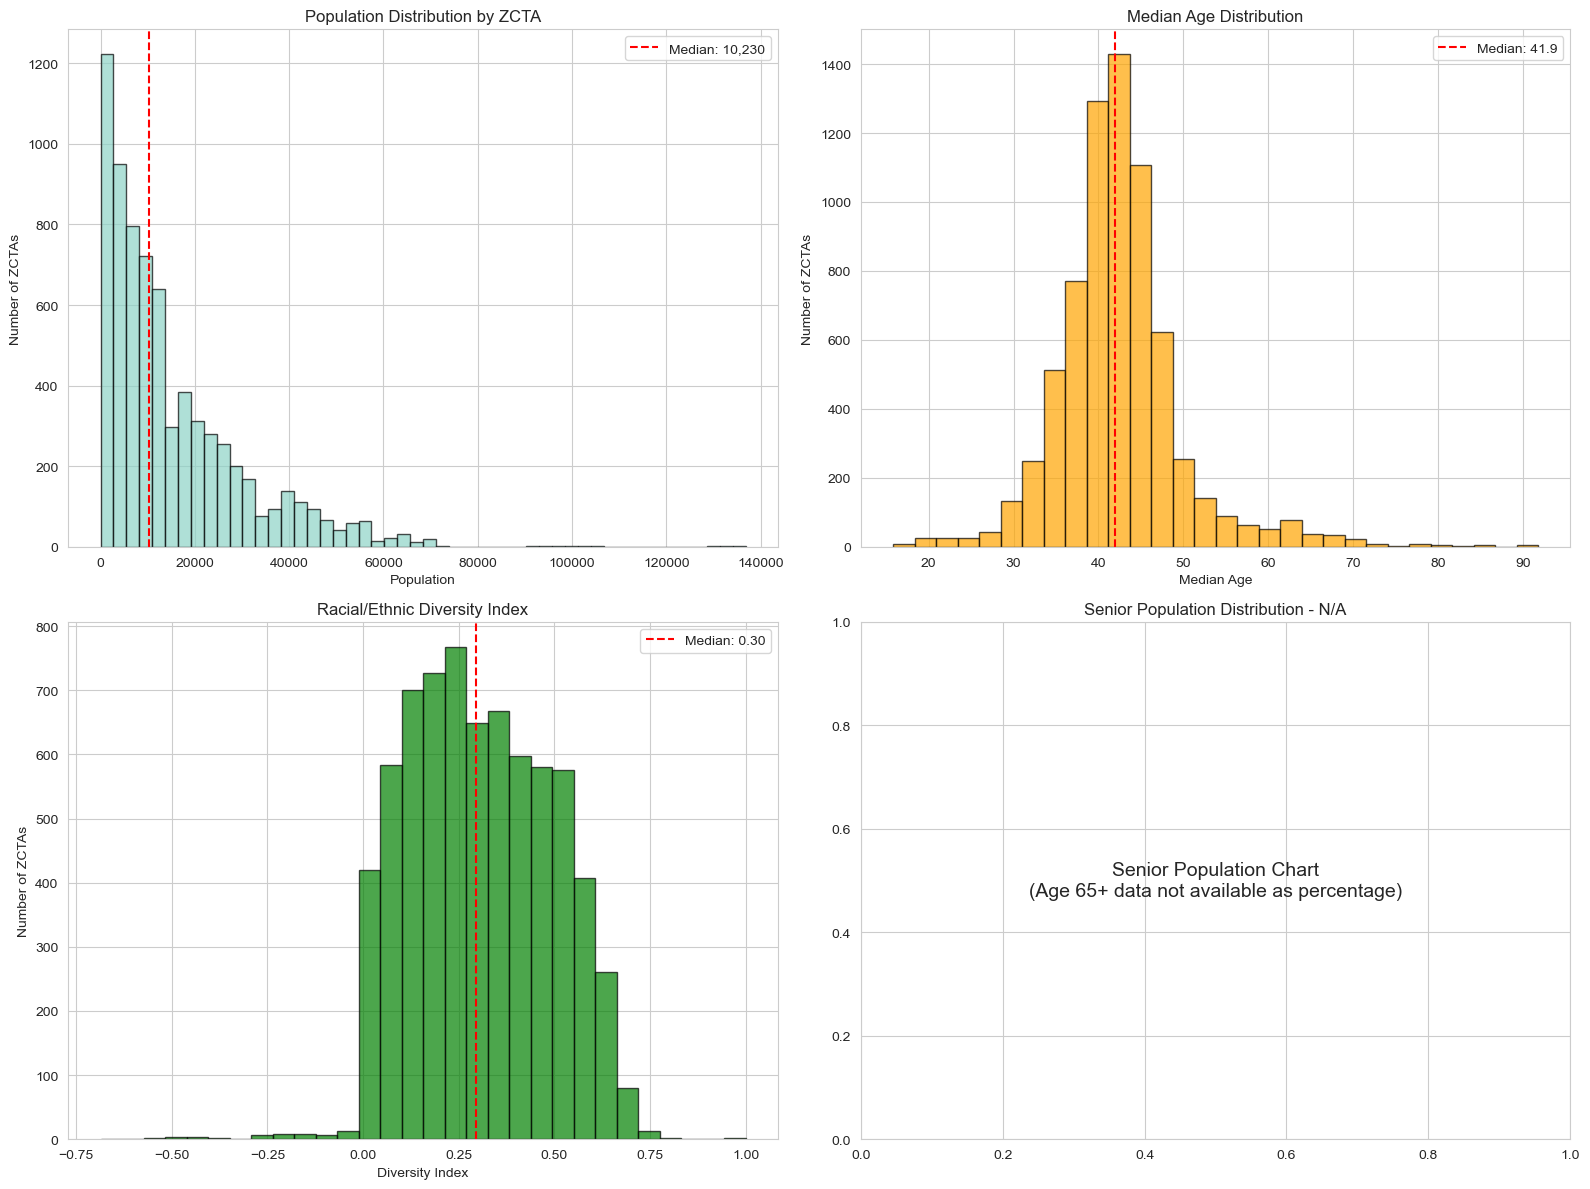

In [10]:
# Population and diversity visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Population distribution
axes[0, 0].hist(nj_zctas['pop_total'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Population')
axes[0, 0].set_ylabel('Number of ZCTAs')
axes[0, 0].set_title('Population Distribution by ZCTA')
axes[0, 0].axvline(nj_zctas['pop_total'].median(), color='red', linestyle='--', 
                   label=f'Median: {nj_zctas["pop_total"].median():,.0f}')
axes[0, 0].legend()

# Age distribution
age_data = conn.execute("""
    SELECT age_median 
    FROM acs_zctas 
    WHERE pop_total > 0 AND age_median IS NOT NULL
""").df()
axes[0, 1].hist(age_data['age_median'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Median Age')
axes[0, 1].set_ylabel('Number of ZCTAs')
axes[0, 1].set_title('Median Age Distribution')
axes[0, 1].axvline(age_data['age_median'].median(), color='red', linestyle='--',
                   label=f'Median: {age_data["age_median"].median():.1f}')
axes[0, 1].legend()

# Diversity index
diversity_data = conn.execute("""
    SELECT diversity_index 
    FROM acs_zctas 
    WHERE pop_total > 0 AND diversity_index IS NOT NULL
""").df()
axes[1, 0].hist(diversity_data['diversity_index'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Diversity Index')
axes[1, 0].set_ylabel('Number of ZCTAs')
axes[1, 0].set_title('Racial/Ethnic Diversity Index')
axes[1, 0].axvline(diversity_data['diversity_index'].median(), color='red', linestyle='--',
                   label=f'Median: {diversity_data["diversity_index"].median():.2f}')
axes[1, 0].legend()

# Note: pct_over_65 doesn't exist - would need age_65plus field to calculate
# Removing senior population chart
axes[1, 1].text(0.5, 0.5, 'Senior Population Chart\n(Age 65+ data not available as percentage)', 
                ha='center', va='center', fontsize=14, transform=axes[1, 1].transAxes)
axes[1, 1].set_title('Senior Population Distribution - N/A')

plt.tight_layout()
plt.show()

## 4. Economic Indicators

In [11]:
# Income statistics
print("\nMedian Household Income Statistics:")
income_data = nj_zctas['income_median_hh'].dropna()
print(income_data.describe())

# Poverty and employment
econ_stats = conn.execute("""
    SELECT
        AVG(income_median_hh) as avg_income,
        AVG(poverty_rate) as avg_poverty_rate,
        AVG(unemployment_rate_acs) as avg_unemployment_rate,
        AVG(pct_bachelors_plus) as avg_bachelors_rate,
        MAX(poverty_rate) as max_poverty_rate,
        MIN(income_median_hh) as min_income
    FROM acs_zctas
    WHERE pop_total > 0
""").df()

print("\nEconomic Indicators:")
display(econ_stats)


Median Household Income Statistics:
count      6855.000000
mean      95155.573158
std       39218.456902
min       13306.000000
25%       68512.000000
50%       88826.000000
75%      114884.000000
max      250001.000000
Name: income_median_hh, dtype: float64

Economic Indicators:


,avg_income,avg_poverty_rate,avg_unemployment_rate,avg_bachelors_rate,max_poverty_rate,min_income
0,95155.573158,8.489318,7.225423,39.957717,100.0,13306.0


In [12]:
# Top and bottom income areas
print("\nTop 15 Highest Income ZCTAs:")
top_income = conn.execute("""
    SELECT geoid, NAME, pop_total, income_median_hh, poverty_rate
    FROM acs_zctas
    WHERE pop_total > 0 AND income_median_hh IS NOT NULL
    ORDER BY income_median_hh DESC
    LIMIT 15
""").df()
display(top_income)

print("\nBottom 15 Lowest Income ZCTAs:")
bottom_income = conn.execute("""
    SELECT geoid, NAME, pop_total, income_median_hh, poverty_rate
    FROM acs_zctas
    WHERE pop_total > 0 AND income_median_hh IS NOT NULL
    ORDER BY income_median_hh ASC
    LIMIT 15
""").df()
display(bottom_income)


Top 15 Highest Income ZCTAs:


,geoid,NAME,pop_total,income_median_hh,poverty_rate
0,07970,ZCTA5 07970,137,250001.0,0.00
1,07970,ZCTA5 07970,132,250001.0,0.00
2,07078,ZCTA5 07078,12855,250001.0,1.87
3,07970,ZCTA5 07970,164,250001.0,0.00
4,07078,ZCTA5 07078,12766,250001.0,1.94
5,07078,ZCTA5 07078,13097,250001.0,1.21
6,07078,ZCTA5 07078,13097,250001.0,1.58
7,07078,ZCTA5 07078,13372,250001.0,4.16
8,07078,ZCTA5 07078,13305,250001.0,3.75
9,07021,ZCTA5 07021,2270,250001.0,1.15



Bottom 15 Lowest Income ZCTAs:


,geoid,NAME,pop_total,income_median_hh,poverty_rate
0,08608,ZCTA5 08608,637,13306.0,48.35
1,08608,ZCTA5 08608,813,13395.0,52.29
2,08608,ZCTA5 08608,946,14740.0,33.48
3,08608,ZCTA5 08608,676,14803.0,28.32
4,08608,ZCTA5 08608,921,14861.0,34.97
5,08608,ZCTA5 08608,889,14886.0,37.67
6,08608,ZCTA5 08608,805,15855.0,26.25
7,08608,ZCTA5 08608,893,16442.0,37.84
8,07881,ZCTA5 07881,4,16667.0,0.00
9,07881,ZCTA5 07881,9,16750.0,0.00


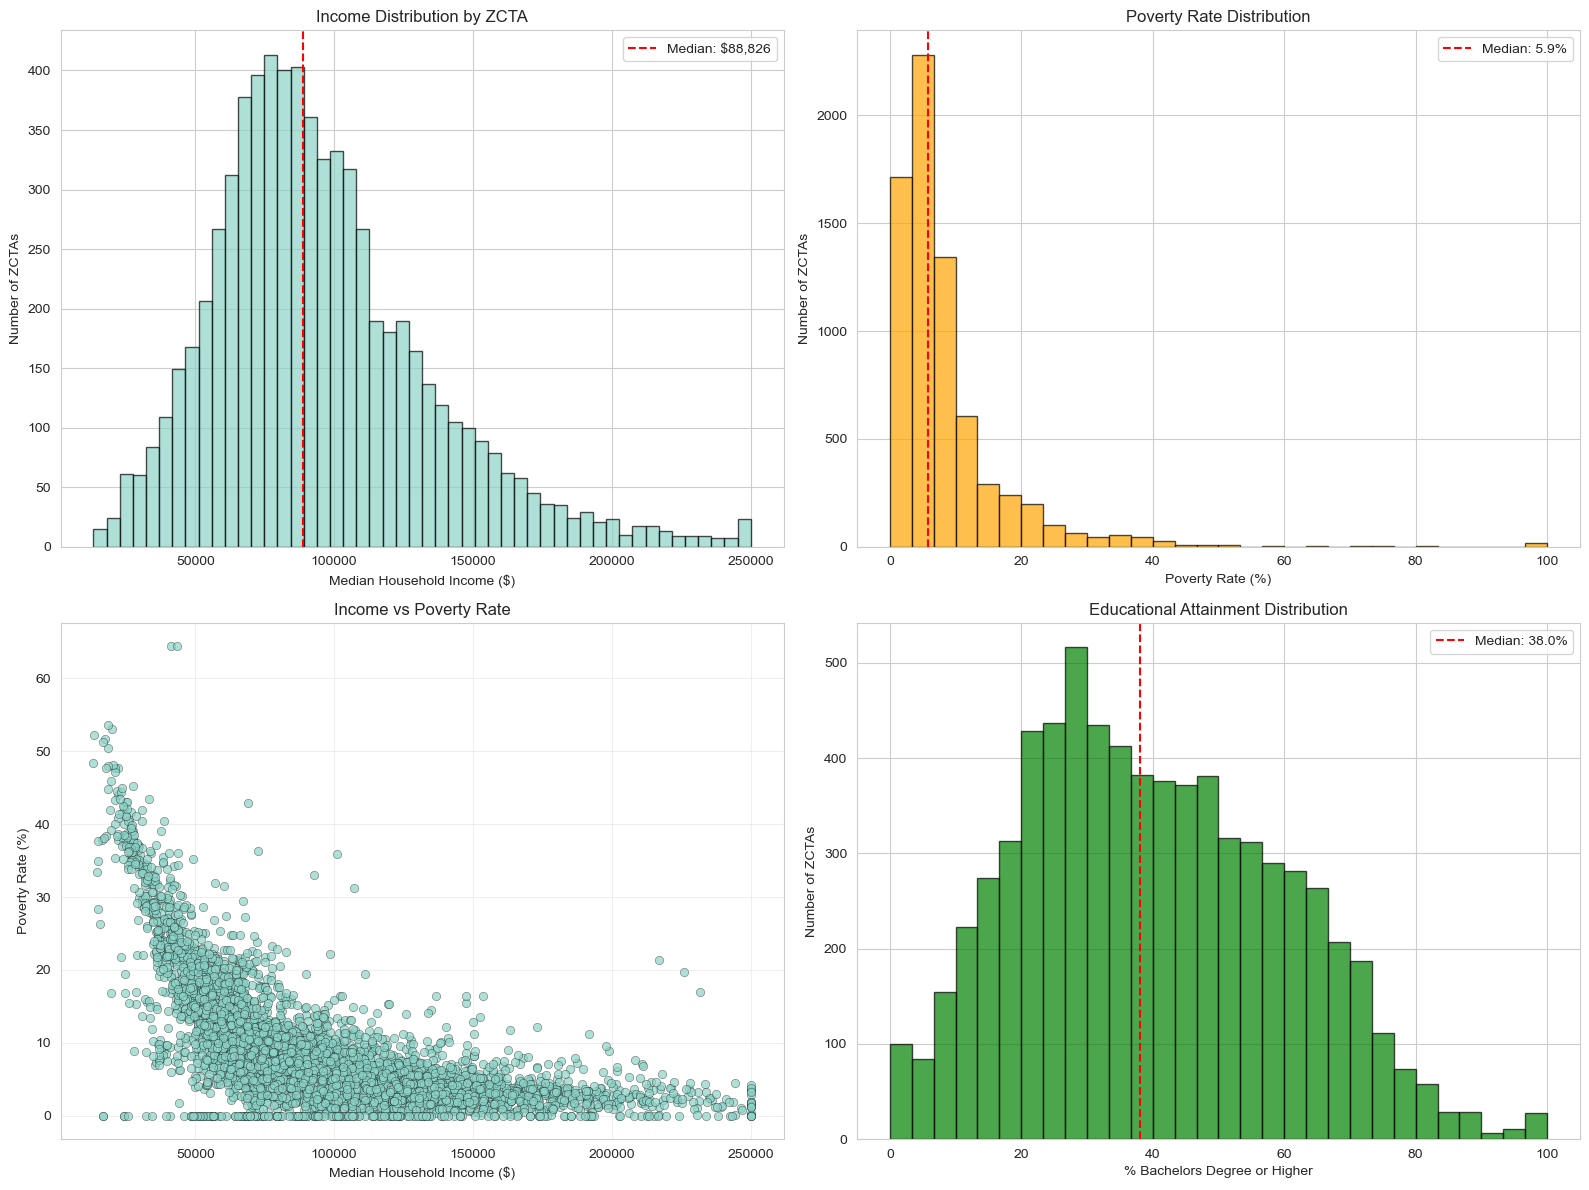

In [13]:
# Economic indicators visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Income distribution
axes[0, 0].hist(income_data, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Median Household Income ($)')
axes[0, 0].set_ylabel('Number of ZCTAs')
axes[0, 0].set_title('Income Distribution by ZCTA')
axes[0, 0].axvline(income_data.median(), color='red', linestyle='--',
                   label=f'Median: ${income_data.median():,.0f}')
axes[0, 0].legend()

# Poverty rate
poverty_data = nj_zctas['poverty_rate'].dropna()
axes[0, 1].hist(poverty_data, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Poverty Rate (%)')
axes[0, 1].set_ylabel('Number of ZCTAs')
axes[0, 1].set_title('Poverty Rate Distribution')
axes[0, 1].axvline(poverty_data.median(), color='red', linestyle='--',
                   label=f'Median: {poverty_data.median():.1f}%')
axes[0, 1].legend()

# Income vs Poverty scatter
scatter_data = nj_zctas[['income_median_hh', 'poverty_rate']].dropna()
axes[1, 0].scatter(scatter_data['income_median_hh'], 
                   scatter_data['poverty_rate'], alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1, 0].set_xlabel('Median Household Income ($)')
axes[1, 0].set_ylabel('Poverty Rate (%)')
axes[1, 0].set_title('Income vs Poverty Rate')
axes[1, 0].grid(True, alpha=0.3)

# Education levels
edu_data = conn.execute("""
    SELECT pct_bachelors_plus 
    FROM acs_zctas 
    WHERE pop_total > 0 AND pct_bachelors_plus IS NOT NULL
""").df()
axes[1, 1].hist(edu_data['pct_bachelors_plus'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('% Bachelors Degree or Higher')
axes[1, 1].set_ylabel('Number of ZCTAs')
axes[1, 1].set_title('Educational Attainment Distribution')
axes[1, 1].axvline(edu_data['pct_bachelors_plus'].median(), color='red', linestyle='--',
                   label=f'Median: {edu_data["pct_bachelors_plus"].median():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 5. Housing Characteristics

In [14]:
# Housing statistics
housing_stats = conn.execute("""
    SELECT
        AVG(home_value_median) as avg_home_value,
        AVG(gross_rent_median) as avg_rent,
        AVG(homeownership_rate) as avg_homeownership_rate,
        AVG(rent_burden_30plus_pct) as avg_rent_burden,
        AVG(rent_burden_severe_pct) as avg_severe_rent_burden,
        MAX(home_value_median) as max_home_value,
        MIN(home_value_median) as min_home_value
    FROM acs_zctas
    WHERE pop_total > 0
""").df()

print("\nHousing Statistics:")
display(housing_stats)


Housing Statistics:


,avg_home_value,avg_rent,avg_homeownership_rate,avg_rent_burden,avg_severe_rent_burden,max_home_value,min_home_value
0,392337.621641,1460.872413,71.902985,46.926058,24.110616,2000001.0,57500.0


In [15]:
# Housing burden analysis
burden_analysis = conn.execute("""
    SELECT 
        geoid,
        NAME,
        pop_total,
        income_median_hh,
        home_value_median,
        gross_rent_median,
        rent_burden_30plus_pct,
        rent_burden_severe_pct,
        homeownership_rate
    FROM acs_zctas
    WHERE pop_total > 0 
        AND rent_burden_severe_pct IS NOT NULL
    ORDER BY rent_burden_severe_pct DESC
    LIMIT 20
""").df()

print("\nTop 20 ZCTAs with Highest Severe Rent Burden:")
display(burden_analysis)


Top 20 ZCTAs with Highest Severe Rent Burden:


,geoid,NAME,pop_total,income_median_hh,home_value_median,gross_rent_median,rent_burden_30plus_pct,rent_burden_severe_pct,homeownership_rate
0,08319,ZCTA5 08319,1333,70461.0,265200.0,NaN,100.0,100.0,99.58
1,08327,ZCTA5 08327,2328,61750.0,192200.0,NaN,100.0,100.0,98.76
2,08316,ZCTA5 08316,430,81212.0,117500.0,NaN,100.0,100.0,94.23
3,08327,ZCTA5 08327,2180,66033.0,199200.0,NaN,100.0,100.0,97.46
4,08038,ZCTA5 08038,107,54107.0,345800.0,725.0,100.0,100.0,60.00
5,08316,ZCTA5 08316,324,55313.0,114900.0,NaN,100.0,100.0,94.52
6,08327,ZCTA5 08327,2235,61094.0,162500.0,NaN,100.0,100.0,94.34
7,08038,ZCTA5 08038,75,56250.0,325000.0,723.0,100.0,100.0,58.33
8,08327,ZCTA5 08327,3538,66563.0,148700.0,NaN,100.0,100.0,96.62
9,08038,ZCTA5 08038,85,NaN,225000.0,723.0,100.0,100.0,60.00


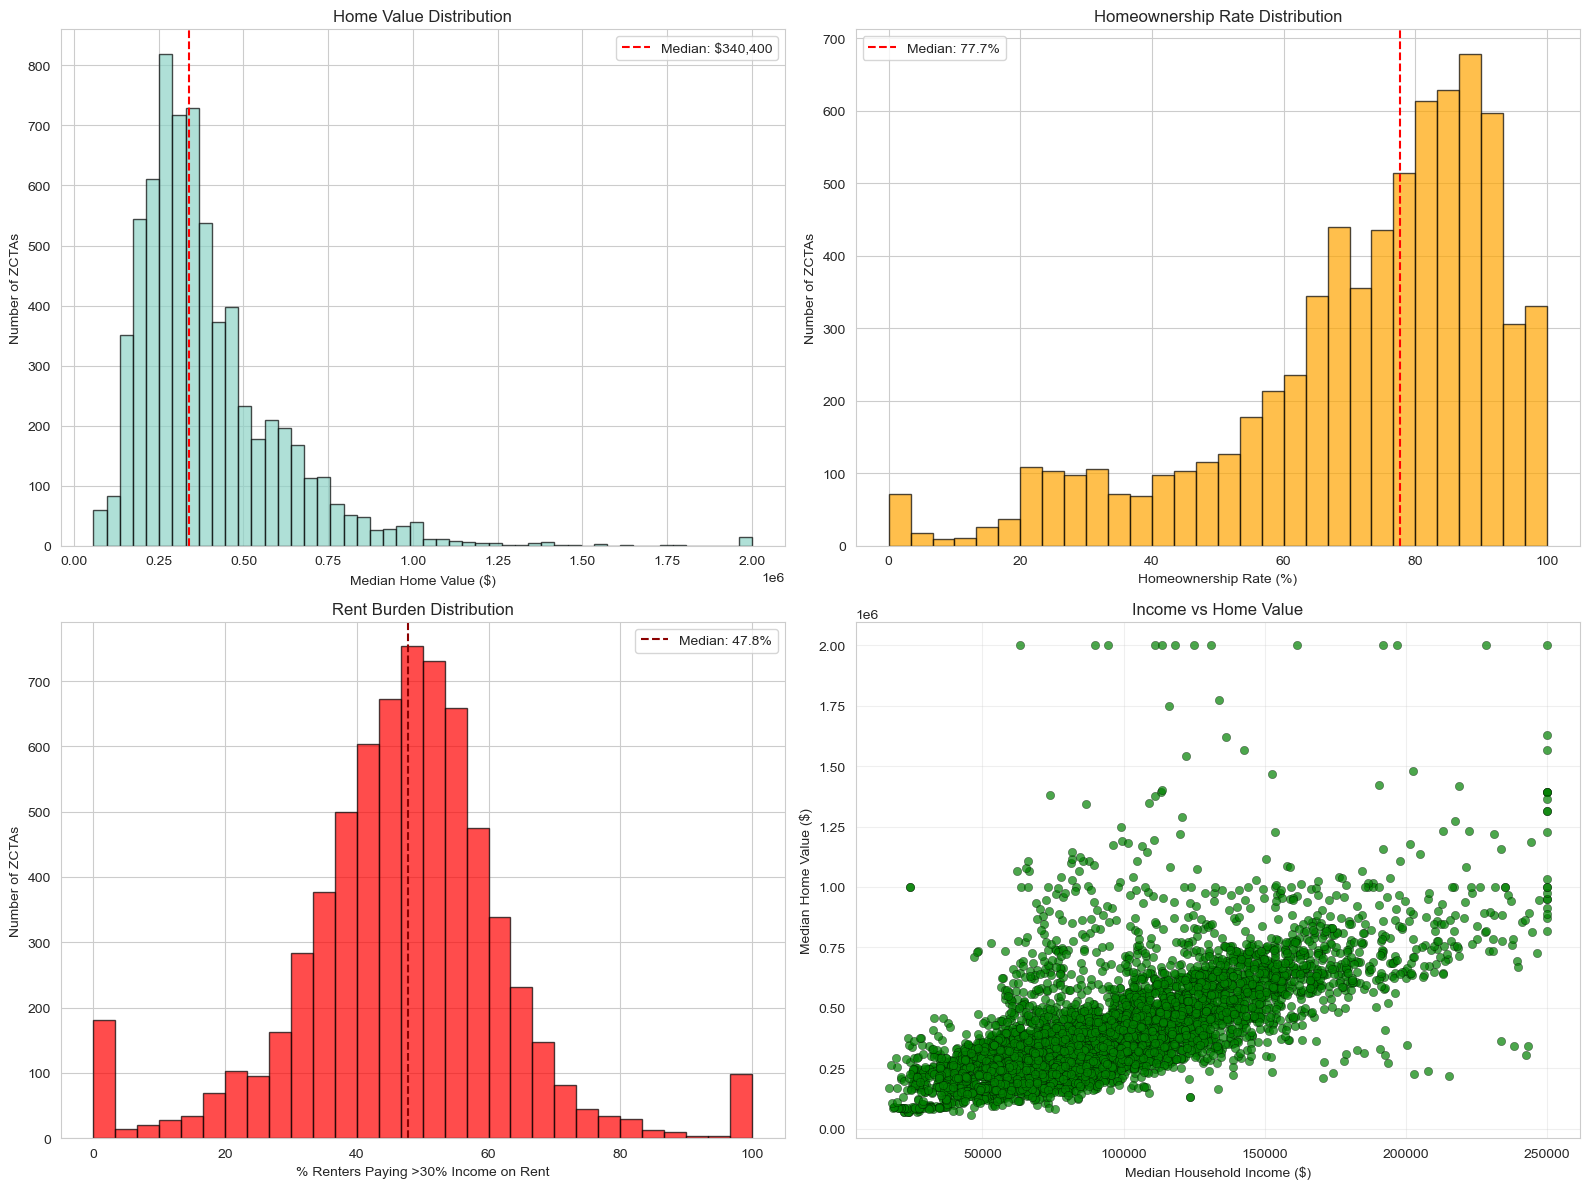

In [16]:
# Housing visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Home values
home_value_data = nj_zctas['home_value_median'].dropna()
axes[0, 0].hist(home_value_data, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Median Home Value ($)')
axes[0, 0].set_ylabel('Number of ZCTAs')
axes[0, 0].set_title('Home Value Distribution')
axes[0, 0].axvline(home_value_data.median(), color='red', linestyle='--',
                   label=f'Median: ${home_value_data.median():,.0f}')
axes[0, 0].legend()

# Homeownership rate
ownership_data = nj_zctas['homeownership_rate'].dropna()
axes[0, 1].hist(ownership_data, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Homeownership Rate (%)')
axes[0, 1].set_ylabel('Number of ZCTAs')
axes[0, 1].set_title('Homeownership Rate Distribution')
axes[0, 1].axvline(ownership_data.median(), color='red', linestyle='--',
                   label=f'Median: {ownership_data.median():.1f}%')
axes[0, 1].legend()

# Rent burden
burden_data = conn.execute("""
    SELECT rent_burden_30plus_pct 
    FROM acs_zctas 
    WHERE pop_total > 0 AND rent_burden_30plus_pct IS NOT NULL
""").df()
axes[1, 0].hist(burden_data['rent_burden_30plus_pct'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].set_xlabel('% Renters Paying >30% Income on Rent')
axes[1, 0].set_ylabel('Number of ZCTAs')
axes[1, 0].set_title('Rent Burden Distribution')
axes[1, 0].axvline(burden_data['rent_burden_30plus_pct'].median(), color='darkred', linestyle='--',
                   label=f'Median: {burden_data["rent_burden_30plus_pct"].median():.1f}%')
axes[1, 0].legend()

# Income vs Home Value
scatter_housing = nj_zctas[['income_median_hh', 'home_value_median']].dropna()
axes[1, 1].scatter(scatter_housing['income_median_hh'],
                   scatter_housing['home_value_median'], alpha=0.7, color='green', edgecolor='black', linewidth=0.3)
axes[1, 1].set_xlabel('Median Household Income ($)')
axes[1, 1].set_ylabel('Median Home Value ($)')
axes[1, 1].set_title('Income vs Home Value')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Vulnerability & Risk Assessment

Identifying areas with higher social vulnerability for disaster preparedness.

In [17]:
# High vulnerability indicators
# Note: pct_over_65, pct_under_18, pct_no_vehicle, pct_limited_english don't exist
# Using available vulnerability indicators
vulnerability_profile = conn.execute("""
    SELECT 
        geoid,
        NAME,
        pop_total,
        income_median_hh,
        poverty_rate,
        unemployment_rate_acs,
        rent_burden_severe_pct
    FROM acs_zctas
    WHERE pop_total > 500
    ORDER BY poverty_rate DESC
    LIMIT 30
""").df()

print("\nTop 30 ZCTAs by Poverty Rate (Potential High Vulnerability):")
display(vulnerability_profile)


Top 30 ZCTAs by Poverty Rate (Potential High Vulnerability):


,geoid,NAME,pop_total,income_median_hh,poverty_rate,unemployment_rate_acs,rent_burden_severe_pct
0,08544,ZCTA5 08544,4504,NaN,100.00,10.45,0.00
1,08544,ZCTA5 08544,4548,NaN,100.00,10.14,0.00
2,08102,ZCTA5 08102,7554,18390.0,53.65,26.09,32.10
3,08102,ZCTA5 08102,7601,20165.0,53.01,24.32,28.45
4,08608,ZCTA5 08608,813,13395.0,52.29,5.54,37.04
5,07505,ZCTA5 07505,4122,17574.0,51.63,29.58,38.13
6,07505,ZCTA5 07505,3303,16821.0,51.26,6.88,40.29
7,08102,ZCTA5 08102,7942,18697.0,50.46,23.67,32.04
8,08608,ZCTA5 08608,637,13306.0,48.35,4.28,32.92
9,08102,ZCTA5 08102,7623,20529.0,48.11,18.42,23.71


In [18]:
# Create composite vulnerability score
# Note: Simplified to use only available columns (removed pct_over_65, pct_no_vehicle)
vulnerability_score = conn.execute("""
    SELECT 
        geoid,
        NAME,
        pop_total,
        income_median_hh,
        poverty_rate,
        unemployment_rate_acs,
        rent_burden_severe_pct,
        -- Simplified composite score using available fields (higher = more vulnerable)
        (COALESCE(poverty_rate, 0) * 2 +
         COALESCE(unemployment_rate_acs, 0) * 2 +
         COALESCE(rent_burden_severe_pct, 0)) / 5 as vulnerability_score
    FROM acs_zctas
    WHERE pop_total > 500
    ORDER BY vulnerability_score DESC
    LIMIT 30
""").df()

print("\nTop 30 ZCTAs by Composite Vulnerability Score:")
display(vulnerability_score)


Top 30 ZCTAs by Composite Vulnerability Score:


,geoid,NAME,pop_total,income_median_hh,poverty_rate,unemployment_rate_acs,rent_burden_severe_pct,vulnerability_score
0,08544,ZCTA5 08544,4504,NaN,100.00,10.45,0.00,44.180
1,08544,ZCTA5 08544,4548,NaN,100.00,10.14,0.00,44.056
2,07505,ZCTA5 07505,4122,17574.0,51.63,29.58,38.13,40.110
3,08102,ZCTA5 08102,7554,18390.0,53.65,26.09,32.10,38.316
4,08102,ZCTA5 08102,7382,18696.0,48.02,28.22,33.93,37.282
5,08102,ZCTA5 08102,7380,17772.0,47.69,26.38,35.96,36.820
6,08103,ZCTA5 08103,14349,23134.0,44.41,25.47,44.05,36.762
7,08102,ZCTA5 08102,7601,20165.0,53.01,24.32,28.45,36.622
8,08103,ZCTA5 08103,14646,21888.0,44.60,23.36,45.11,36.206
9,08102,ZCTA5 08102,7942,18697.0,50.46,23.67,32.04,36.060


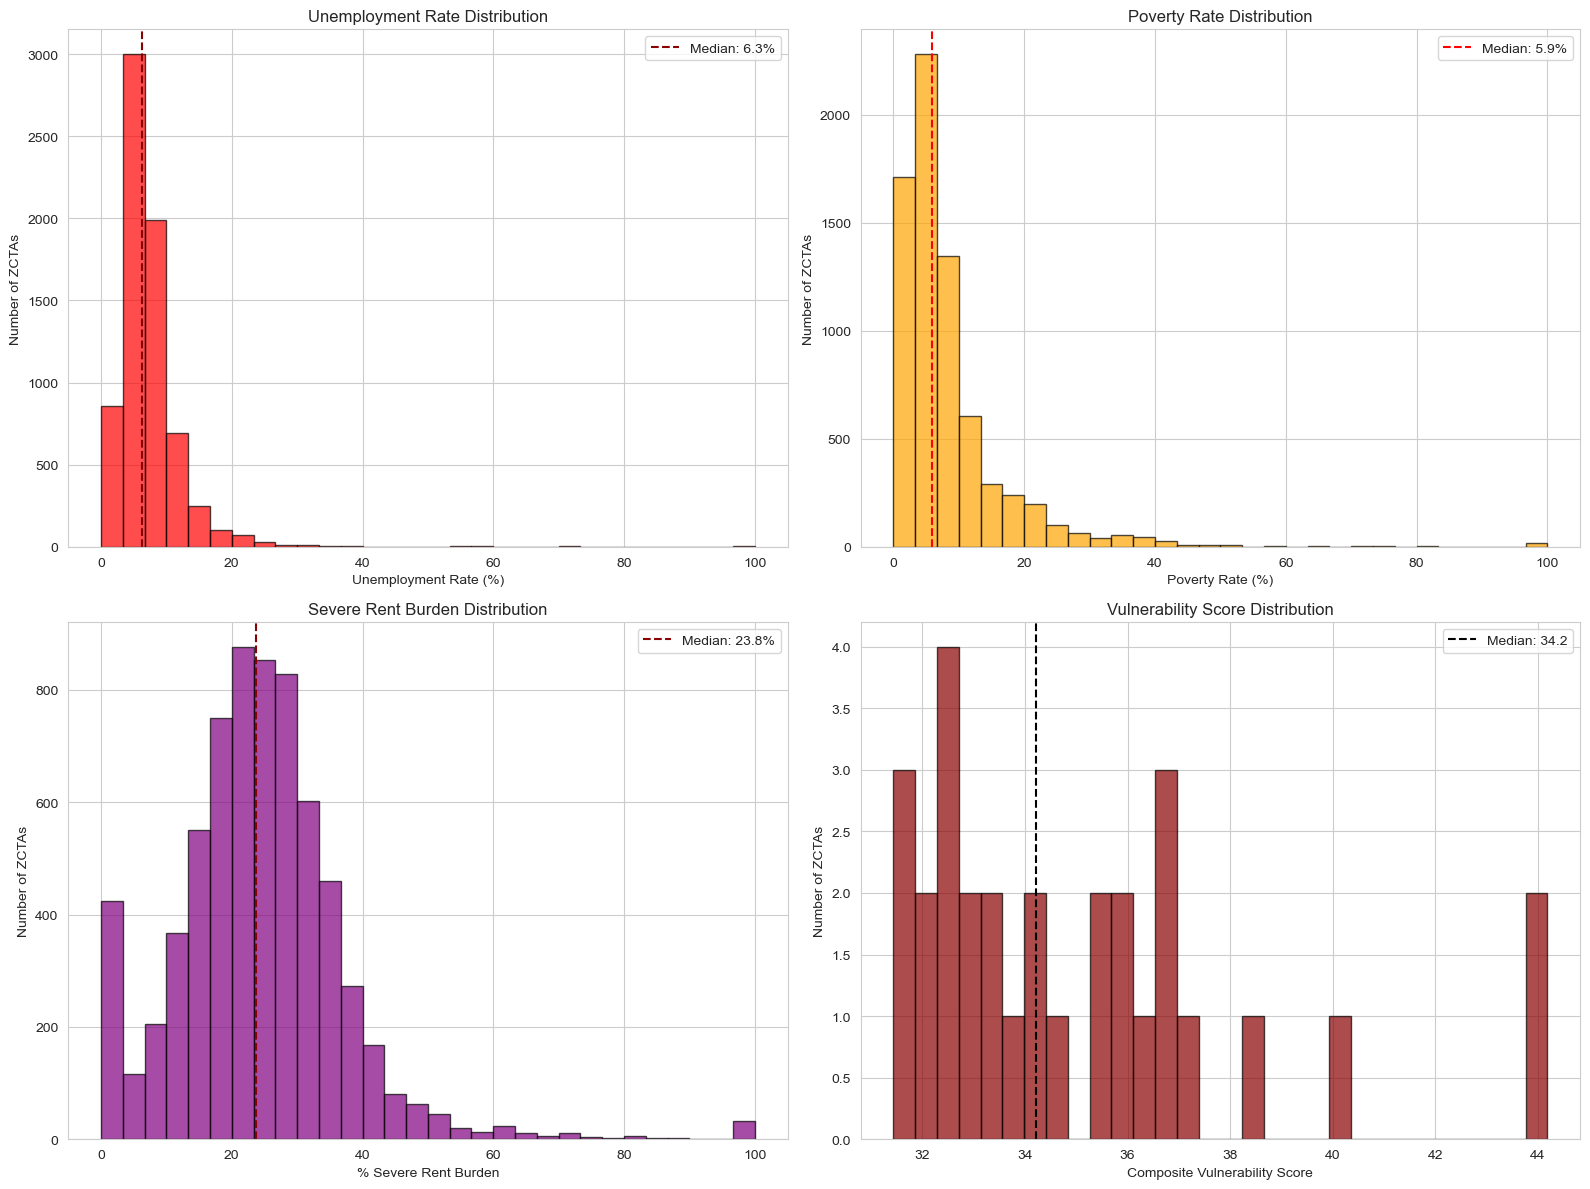

In [19]:
# Vulnerability indicators visualization
# Note: pct_no_vehicle, pct_limited_english, pct_disability don't exist in the schema
# Showing available vulnerability indicators instead

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Unemployment rate
unemployment_data = conn.execute("""
    SELECT unemployment_rate_acs 
    FROM acs_zctas 
    WHERE pop_total > 0 AND unemployment_rate_acs IS NOT NULL
""").df()
axes[0, 0].hist(unemployment_data['unemployment_rate_acs'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[0, 0].set_xlabel('Unemployment Rate (%)')
axes[0, 0].set_ylabel('Number of ZCTAs')
axes[0, 0].set_title('Unemployment Rate Distribution')
axes[0, 0].axvline(unemployment_data['unemployment_rate_acs'].median(), color='darkred', linestyle='--',
                   label=f'Median: {unemployment_data["unemployment_rate_acs"].median():.1f}%')
axes[0, 0].legend()

# Poverty rate
poverty_viz_data = conn.execute("""
    SELECT poverty_rate 
    FROM acs_zctas 
    WHERE pop_total > 0 AND poverty_rate IS NOT NULL
""").df()
axes[0, 1].hist(poverty_viz_data['poverty_rate'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Poverty Rate (%)')
axes[0, 1].set_ylabel('Number of ZCTAs')
axes[0, 1].set_title('Poverty Rate Distribution')
axes[0, 1].axvline(poverty_viz_data['poverty_rate'].median(), color='red', linestyle='--',
                   label=f'Median: {poverty_viz_data["poverty_rate"].median():.1f}%')
axes[0, 1].legend()

# Severe rent burden
severe_burden_data = conn.execute("""
    SELECT rent_burden_severe_pct 
    FROM acs_zctas 
    WHERE pop_total > 0 AND rent_burden_severe_pct IS NOT NULL
""").df()
axes[1, 0].hist(severe_burden_data['rent_burden_severe_pct'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_xlabel('% Severe Rent Burden')
axes[1, 0].set_ylabel('Number of ZCTAs')
axes[1, 0].set_title('Severe Rent Burden Distribution')
axes[1, 0].axvline(severe_burden_data['rent_burden_severe_pct'].median(), color='darkred', linestyle='--',
                   label=f'Median: {severe_burden_data["rent_burden_severe_pct"].median():.1f}%')
axes[1, 0].legend()

# Vulnerability score
axes[1, 1].hist(vulnerability_score['vulnerability_score'], bins=30, edgecolor='black', alpha=0.7, color='darkred')
axes[1, 1].set_xlabel('Composite Vulnerability Score')
axes[1, 1].set_ylabel('Number of ZCTAs')
axes[1, 1].set_title('Vulnerability Score Distribution')
axes[1, 1].axvline(vulnerability_score['vulnerability_score'].median(), color='black', linestyle='--',
                   label=f'Median: {vulnerability_score["vulnerability_score"].median():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Key Findings Summary

In [20]:
# Calculate key statistics
summary_stats = conn.execute("""
    SELECT
        COUNT(DISTINCT geoid) as total_zctas,
        SUM(pop_total) as total_population,
        ROUND(AVG(income_median_hh), 0) as avg_income,
        ROUND(MEDIAN(income_median_hh), 0) as median_income,
        ROUND(AVG(poverty_rate), 1) as avg_poverty_rate,
        ROUND(AVG(homeownership_rate), 1) as avg_homeownership,
        ROUND(AVG(home_value_median), 0) as avg_home_value,
        ROUND(MEDIAN(home_value_median), 0) as median_home_value,
        ROUND(AVG(rent_burden_severe_pct), 1) as avg_severe_rent_burden,
        ROUND(AVG(age_median), 1) as avg_median_age
    FROM acs_zctas
    WHERE pop_total > 0
""").df()

print("=" * 70)
print("KEY FINDINGS - CENSUS/ACS DATA")
print("=" * 70)

print(f"\n1. COVERAGE")
print(f"   • {summary_stats['total_zctas'].iloc[0]:,} ZIP Code Tabulation Areas")
print(f"   • Total population: {summary_stats['total_population'].iloc[0]:,}")

print(f"\n2. DEMOGRAPHICS")
print(f"   • Average median age: {summary_stats['avg_median_age'].iloc[0]:.1f} years")

print(f"\n3. ECONOMIC PROFILE")
print(f"   • Median household income: ${summary_stats['median_income'].iloc[0]:,.0f}")
print(f"   • Average poverty rate: {summary_stats['avg_poverty_rate'].iloc[0]:.1f}%")

print(f"\n4. HOUSING")
print(f"   • Median home value: ${summary_stats['median_home_value'].iloc[0]:,.0f}")
print(f"   • Average homeownership rate: {summary_stats['avg_homeownership'].iloc[0]:.1f}%")
print(f"   • Average severe rent burden: {summary_stats['avg_severe_rent_burden'].iloc[0]:.1f}%")

print(f"\n5. HIGHEST INCOME ZCTA")
top1 = top_income.iloc[0]
print(f"   • {top1['geoid']} ({top1['NAME']}): ${top1['income_median_hh']:,.0f}")

print(f"\n6. MOST VULNERABLE ZCTA")
vuln1 = vulnerability_score.iloc[0]
print(f"   • {vuln1['geoid']} ({vuln1['NAME']})")
print(f"   • Vulnerability score: {vuln1['vulnerability_score']:.1f}")
print(f"   • Poverty rate: {vuln1['poverty_rate']:.1f}%")

print("\n" + "=" * 70)

KEY FINDINGS - CENSUS/ACS DATA

1. COVERAGE
   • 599 ZIP Code Tabulation Areas
   • Total population: 107,676,527.0

2. DEMOGRAPHICS
   • Average median age: 42.4 years

3. ECONOMIC PROFILE
   • Median household income: $88,826
   • Average poverty rate: 8.5%

4. HOUSING
   • Median home value: $340,400
   • Average homeownership rate: 71.9%
   • Average severe rent burden: 24.1%

5. HIGHEST INCOME ZCTA
   • 07970 (ZCTA5 07970): $250,001

6. MOST VULNERABLE ZCTA
   • 08544 (ZCTA5 08544)
   • Vulnerability score: 44.2
   • Poverty rate: 100.0%



## 8. Geographic Distribution of Key Metrics

Fetching geographical coordinates for ZCTAs...


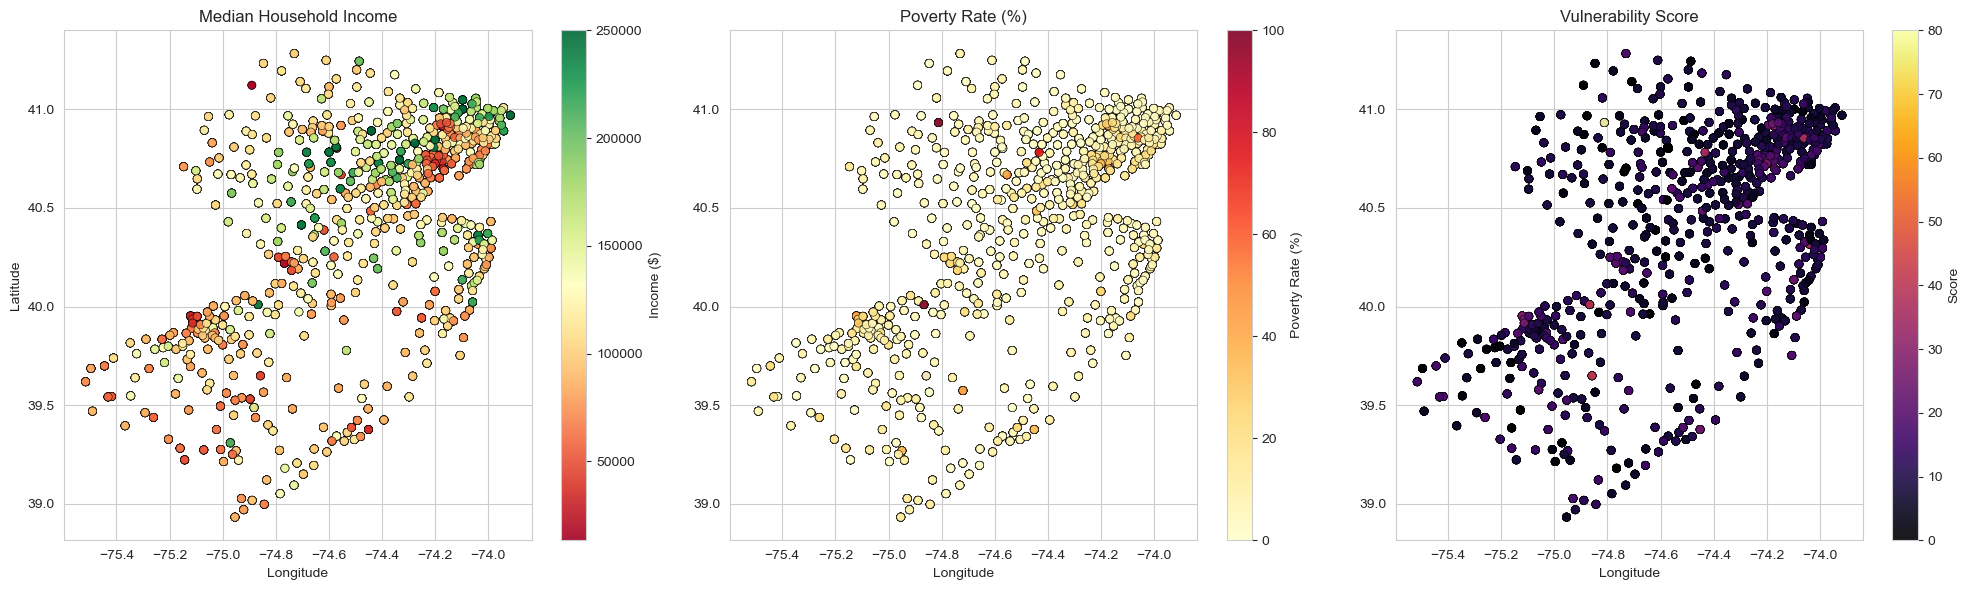

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Fetch key metrics from the database
geo_data = conn.execute("""
    SELECT
        geoid as zcta,
        income_median_hh,
        poverty_rate,
        (COALESCE(poverty_rate, 0) * 2 +
         COALESCE(unemployment_rate_acs, 0) * 2 +
         COALESCE(rent_burden_severe_pct, 0)) / 5 as vulnerability_score
    FROM acs_zctas
    WHERE pop_total > 0
""").df()

# Fetch ZCTA coordinates from a public gist (US Census 2013 data)
print("Fetching geographical coordinates for ZCTAs...")
url = "https://gist.githubusercontent.com/erichurst/7882666/raw/5bdc46db47d9515269ab12ed6fb2850377fd869e/US%2520Zip%2520Codes%2520from%25202013%2520Government%2520Data"
try:
    zip_coords = pd.read_csv(url)
    zip_coords['ZIP'] = zip_coords['ZIP'].astype(str).str.zfill(5)

    # Merge metrics with coordinates
    geo_data = geo_data.merge(zip_coords, left_on='zcta', right_on='ZIP', how='inner')

    if not geo_data.empty:
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # Income
        sc1 = axes[0].scatter(geo_data['LNG'], geo_data['LAT'],
                              c=geo_data['income_median_hh'], cmap='RdYlGn',
                              alpha=0.9, s=35, edgecolor='black', linewidth=0.4)
        axes[0].set_title('Median Household Income')
        axes[0].set_xlabel('Longitude')
        axes[0].set_ylabel('Latitude')
        plt.colorbar(sc1, ax=axes[0], label='Income ($)')

        # Poverty Rate
        sc2 = axes[1].scatter(geo_data['LNG'], geo_data['LAT'],
                              c=geo_data['poverty_rate'], cmap='YlOrRd',
                              alpha=0.9, s=35, edgecolor='black', linewidth=0.4)
        axes[1].set_title('Poverty Rate (%)')
        axes[1].set_xlabel('Longitude')
        plt.colorbar(sc2, ax=axes[1], label='Poverty Rate (%)')

        # Vulnerability Score
        sc3 = axes[2].scatter(geo_data['LNG'], geo_data['LAT'],
                              c=geo_data['vulnerability_score'], cmap='inferno',
                              alpha=0.9, s=35, edgecolor='black', linewidth=0.4)
        axes[2].set_title('Vulnerability Score')
        axes[2].set_xlabel('Longitude')
        plt.colorbar(sc3, ax=axes[2], label='Score')

        plt.tight_layout()
        plt.show()
    else:
        print("Failed to merge zip codes with coordinates.")
except Exception as e:
    print(f"Could not fetch or process coordinate data: {e}")

In [22]:
conn.close()
print("\nAnalysis complete. Database connection closed.")


Analysis complete. Database connection closed.
